# primesense 🎬
## Notebook 04 — BERT Fine-Tuning for Sentiment Classification

---

### 🗺️ About This Notebook

This notebook takes our sentiment classifier to the next level using **BERT** — Bidirectional Encoder Representations from Transformers. Unlike the classical models in Notebook 03 which treat text as a bag of words, BERT reads text **bidirectionally**, understanding the full context of each word based on all surrounding words.

For example, the word *'fine'* in:
- *'The show was fine'* → neutral/negative
- *'Fine acting, incredible story'* → positive

TF-IDF cannot distinguish these. BERT can.

---

### 🎯 What This Notebook Does

1. Load and sample the processed dataset for BERT training
2. Tokenize reviews using `bert-base-uncased` tokenizer
3. Build a PyTorch Dataset and DataLoader
4. Fine-tune BERT with a classification head
5. Train with live epoch-by-epoch progress display
6. Evaluate on the held-out test set
7. Compare against our best classical model (Tuned SVM)
8. Save the fine-tuned model

---

### ⚙️ Local vs Colab

The original notebook was built for Google Colab with a T4 GPU. This version is fully adapted for **local execution** in VS Code / WSL with CPU. Training on CPU is slower but completely functional.

> 💡 **Tip:** To keep training time reasonable locally, we train on a **stratified sample** of the data rather than all 233K reviews. You can increase `SAMPLE_SIZE` if you have time or access to a GPU.

---
## 4.0 Imports & Configuration

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

with open('../config.yaml', 'r') as f:
    CONFIG = yaml.safe_load(f)

BERT_CFG     = CONFIG['models']['bert']
RANDOM_STATE = CONFIG['data']['random_state']
FIGURES_PATH = '../reports/figures/'
MODELS_PATH  = f"../{BERT_CFG['saved_path']}"
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH,  exist_ok=True)

# ── Device setup ──────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded.')
print(f'   Device       : {DEVICE}')
if DEVICE.type == 'cpu':
    print(f'   ⚠️  Running on CPU — training will be slower.')
    print(f'      Tip: Reduce SAMPLE_SIZE below if needed.')
else:
    print(f'   ✅ GPU available — full speed ahead!')

✅ Libraries loaded.
   Device       : cpu
   ⚠️  Running on CPU — training will be slower.
      Tip: Reduce SAMPLE_SIZE below if needed.


---
## 4.1 Load & Sample Data

BERT is computationally expensive. On CPU, training on all 233K reviews would take many hours. We use a **stratified sample** that preserves class proportions while keeping training time manageable.

Adjust `SAMPLE_SIZE` based on your hardware:
- CPU only → `5000` (fast, ~20–30 min)
- CPU with patience → `10000` (~1–2 hours)
- GPU → `50000` (reasonable)

In [2]:
SAMPLE_SIZE = 5000   # Adjust based on your hardware

df = pd.read_csv('../data/processed/reviews_model.csv')
df = df.dropna(subset=['review_text', 'sentiment']).reset_index(drop=True)

# Stratified sample — preserves class proportions
df_sample, _ = train_test_split(
    df,
    train_size=min(SAMPLE_SIZE, len(df)),
    stratify=df['sentiment'],
    random_state=RANDOM_STATE
)
df_sample = df_sample.reset_index(drop=True)

print(f'✅ Sampled {len(df_sample):,} reviews for BERT training')
print()
print('Class Distribution in Sample:')
print('=' * 40)
for label, count in df_sample['sentiment'].value_counts().items():
    pct = count / len(df_sample) * 100
    print(f'  {label:<10}: {count:>5,}  ({pct:.1f}%)')

✅ Sampled 5,000 reviews for BERT training

Class Distribution in Sample:
  positive  : 3,783  (75.7%)
  negative  :   715  (14.3%)
  neutral   :   502  (10.0%)


---
## 4.2 Encode Labels

BERT's classification head expects integer labels, not strings. We encode our sentiment labels consistently:
`negative=0`, `neutral=1`, `positive=2`

In [3]:
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df_sample['label'] = df_sample['sentiment'].map(LABEL2ID)

print('Label Encoding:')
for label, idx in LABEL2ID.items():
    print(f'  {label:<10} → {idx}')

Label Encoding:
  negative   → 0
  neutral    → 1
  positive   → 2


---
## 4.3 Tokenization

BERT does not work with raw text — it requires **tokenized input** in a specific format:
- `input_ids` — token IDs from BERT's vocabulary
- `attention_mask` — 1 for real tokens, 0 for padding

We use `bert-base-uncased` — a 110M parameter model pretrained on BooksCorpus and English Wikipedia. 'Uncased' means it lowercases all text before tokenizing.

In [4]:
MODEL_NAME = BERT_CFG['model_name']
MAX_LENGTH = BERT_CFG['max_length']

print(f'⏳ Loading tokenizer: {MODEL_NAME}...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer loaded.')
print(f'   Max sequence length: {MAX_LENGTH} tokens')

# Quick example to show what tokenization looks like
example = "Absolutely loved this series, best thing on Prime!"
encoded = tokenizer(example, max_length=MAX_LENGTH,
                    truncation=True, padding='max_length',
                    return_tensors='pt')
print(f'\n📝 Tokenization example:')
print(f'   Input text    : "{example}"')
print(f'   Input IDs     : {encoded["input_ids"][0][:10].tolist()}... (first 10)')
print(f'   Attention mask: {encoded["attention_mask"][0][:10].tolist()}... (first 10)')
print(f'   Tokens        : {tokenizer.convert_ids_to_tokens(encoded["input_ids"][0][:10].tolist())}')

⏳ Loading tokenizer: bert-base-uncased...
✅ Tokenizer loaded.
   Max sequence length: 128 tokens

📝 Tokenization example:
   Input text    : "Absolutely loved this series, best thing on Prime!"
   Input IDs     : [101, 7078, 3866, 2023, 2186, 1010, 2190, 2518, 2006, 3539]... (first 10)
   Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]... (first 10)
   Tokens        : ['[CLS]', 'absolutely', 'loved', 'this', 'series', ',', 'best', 'thing', 'on', 'prime']


---
## 4.4 PyTorch Dataset & DataLoaders

We wrap our data in a custom PyTorch `Dataset` class and create `DataLoader` objects that batch and shuffle the data during training.

In [5]:
class SentimentDataset(Dataset):
    """PyTorch Dataset for BERT sentiment classification."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Train / validation / test split
X = df_sample['review_text'].tolist()
y = df_sample['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

BATCH_SIZE = BERT_CFG['batch_size']

train_dataset = SentimentDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = SentimentDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = SentimentDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print('✅ Datasets and DataLoaders ready.')
print(f'   Training   : {len(train_dataset):,} reviews  ({len(train_loader)} batches)')
print(f'   Validation : {len(val_dataset):,} reviews  ({len(val_loader)} batches)')
print(f'   Test       : {len(test_dataset):,} reviews  ({len(test_loader)} batches)')
print(f'   Batch size : {BATCH_SIZE}')

✅ Datasets and DataLoaders ready.
   Training   : 3,500 reviews  (219 batches)
   Validation : 750 reviews  (47 batches)
   Test       : 750 reviews  (47 batches)
   Batch size : 16


---
## 4.5 Load BERT Model

`BertForSequenceClassification` is BERT with a linear classification head on top of the `[CLS]` token output. We set `num_labels=3` for our three sentiment classes.

In [6]:
NUM_LABELS = 3

print(f'⏳ Loading {MODEL_NAME}...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅ Model loaded and moved to {DEVICE}.')
print(f'   Total parameters    : {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}')

⏳ Loading bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded and moved to cpu.
   Total parameters    : 109,484,547
   Trainable parameters: 109,484,547


---
## 4.6 Training Setup

We use:
- **AdamW optimizer** — Adam with weight decay, standard for transformers
- **Linear warmup scheduler** — gradually increases learning rate then decays it
- **Cross-entropy loss** — built into `BertForSequenceClassification`

In [7]:
EPOCHS       = BERT_CFG['epochs']
LR           = BERT_CFG['learning_rate']
WARMUP_STEPS = int(0.1 * len(train_loader) * EPOCHS)
TOTAL_STEPS  = len(train_loader) * EPOCHS

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS
)

print('✅ Optimizer and scheduler configured.')
print(f'   Epochs         : {EPOCHS}')
print(f'   Learning rate  : {LR}')
print(f'   Total steps    : {TOTAL_STEPS}')
print(f'   Warmup steps   : {WARMUP_STEPS}')

✅ Optimizer and scheduler configured.
   Epochs         : 3
   Learning rate  : 2e-05
   Total steps    : 657
   Warmup steps   : 65


---
## 4.7 Training Loop

We train for `N` epochs. After each epoch we evaluate on the validation set and print a full progress report. This is where the **epoch-by-epoch display** you wanted lives — you can watch the model learn in real time.

In [8]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Run one full training epoch. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss = outputs.loss
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        # Print batch progress every 10 batches
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(loader):
            print(f'    Batch {batch_idx+1:>3}/{len(loader)} '
                  f'| Loss: {total_loss/(batch_idx+1):.4f} '
                  f'| Acc: {correct/total*100:.1f}%',
                  end='\r')
    print()
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    """Evaluate model on a DataLoader. Returns loss, accuracy, and all predictions."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


print('✅ Training functions defined. Ready to train.')

✅ Training functions defined. Ready to train.


In [9]:
history = {'train_loss': [], 'train_acc': [],
           'val_loss'  : [], 'val_acc'  : []}

best_val_acc  = 0
best_val_f1   = 0

print('🚀 Starting BERT Fine-Tuning')
print('=' * 55)
print(f'   Model   : {MODEL_NAME}')
print(f'   Epochs  : {EPOCHS}')
print(f'   Device  : {DEVICE}')
print(f'   Batches : {len(train_loader)} per epoch')
print('=' * 55)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    sep = '-' * 55

    print(f'\n{sep}')
    print(f'  Epoch {epoch}/{EPOCHS}')
    print(f'{sep}')

    # ── Training ──────────────────────────────────────────────
    print('  [Training]')
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, DEVICE
    )

    # ── Validation ────────────────────────────────────────────
    print('  [Validation]')
    val_loss, val_acc, val_preds, val_labels = eval_epoch(
        model, val_loader, DEVICE
    )
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    epoch_time = time.time() - epoch_start

    # ── Epoch summary ─────────────────────────────────────────
    print(f'\n  📊 Epoch {epoch} Results:')
    print(f'     Train Loss : {train_loss:.4f}  |  Train Acc : {train_acc*100:.2f}%')
    print(f'     Val Loss   : {val_loss:.4f}  |  Val Acc   : {val_acc*100:.2f}%')
    print(f'     Val F1 Mac : {val_f1:.4f}')
    print(f'     Time       : {epoch_time:.1f}s')

    # Track best model
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_val_acc = val_acc
        model.save_pretrained(MODELS_PATH)
        tokenizer.save_pretrained(MODELS_PATH)
        print(f'     ✅ New best model saved (F1: {best_val_f1:.4f})')

    # Log history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

total_time = time.time() - total_start
print(f'\n{"="*55}')
print(f'🎉 Training Complete!')
print(f'   Total time     : {total_time/60:.1f} minutes')
print(f'   Best Val Acc   : {best_val_acc*100:.2f}%')
print(f'   Best Val F1    : {best_val_f1:.4f}')
print(f'   Model saved to : {MODELS_PATH}')

🚀 Starting BERT Fine-Tuning
   Model   : bert-base-uncased
   Epochs  : 3
   Device  : cpu
   Batches : 219 per epoch

-------------------------------------------------------
  Epoch 1/3
-------------------------------------------------------
  [Training]
    Batch 219/219 | Loss: 0.6219 | Acc: 74.9%
  [Validation]

  📊 Epoch 1 Results:
     Train Loss : 0.6219  |  Train Acc : 74.91%
     Val Loss   : 0.3976  |  Val Acc   : 85.33%
     Val F1 Mac : 0.6408
     Time       : 8116.6s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     ✅ New best model saved (F1: 0.6408)

-------------------------------------------------------
  Epoch 2/3
-------------------------------------------------------
  [Training]
    Batch 219/219 | Loss: 0.3428 | Acc: 87.1%
  [Validation]

  📊 Epoch 2 Results:
     Train Loss : 0.3428  |  Train Acc : 87.09%
     Val Loss   : 0.3831  |  Val Acc   : 86.40%
     Val F1 Mac : 0.6864
     Time       : 3041.5s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     ✅ New best model saved (F1: 0.6864)

-------------------------------------------------------
  Epoch 3/3
-------------------------------------------------------
  [Training]
    Batch 219/219 | Loss: 0.2179 | Acc: 92.4%
  [Validation]

  📊 Epoch 3 Results:
     Train Loss : 0.2179  |  Train Acc : 92.40%
     Val Loss   : 0.3931  |  Val Acc   : 87.07%
     Val F1 Mac : 0.7192
     Time       : 2987.8s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     ✅ New best model saved (F1: 0.7192)

🎉 Training Complete!
   Total time     : 236.1 minutes
   Best Val Acc   : 87.07%
   Best Val F1    : 0.7192
   Model saved to : ../models/bert_model/


---
## 4.8 Training Curves

Visualizing loss and accuracy over epochs helps us understand whether the model is learning, overfitting, or underfitting.

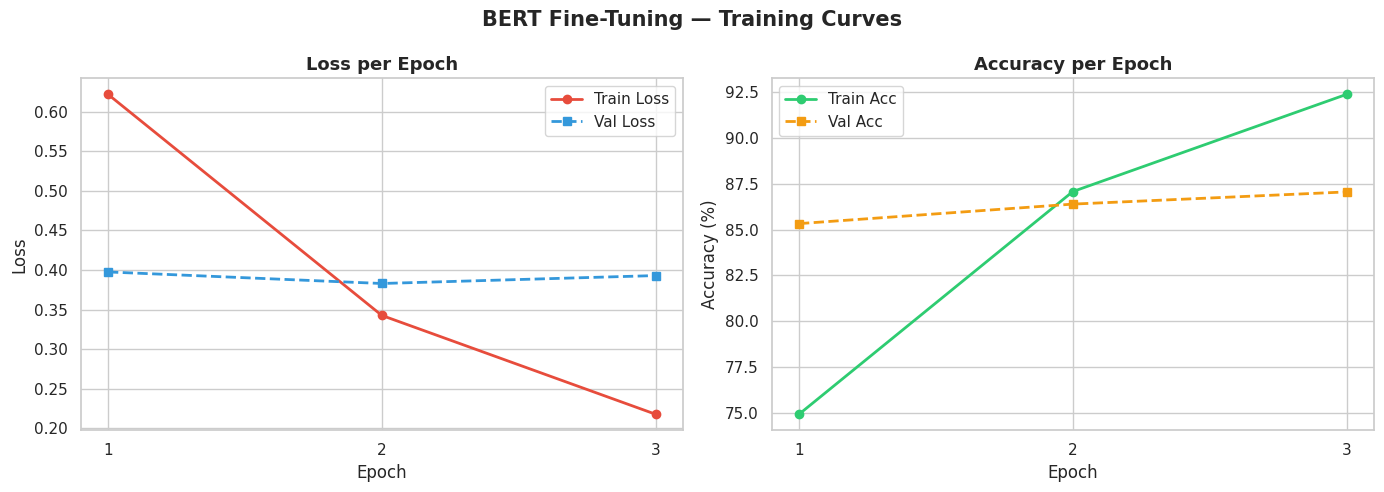

💾 Saved → reports/figures/bert_training_curves.png


In [10]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss',
             color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   's--', label='Val Loss',
             color='#3498db', linewidth=2)
axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(list(epochs_range))

# Accuracy curves
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'o-',
             label='Train Acc', color='#2ecc71', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   's--',
             label='Val Acc',   color='#f39c12', linewidth=2)
axes[1].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].set_xticks(list(epochs_range))

plt.suptitle('BERT Fine-Tuning — Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/bert_training_curves.png')

---
## 4.9 Final Evaluation on Test Set

We load the best saved model and evaluate it on the held-out test set — data the model has never seen during training or validation.

📦 Loading best model from ../models/bert_model/...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  BERT (Fine-Tuned) — Test Set Results
  Accuracy    : 0.8560  (85.60%)
  F1 Macro    : 0.6916
  F1 Weighted : 0.8507

              precision    recall  f1-score   support

    negative       0.74      0.76      0.75       107
     neutral       0.45      0.36      0.40        76
    positive       0.92      0.94      0.93       567

    accuracy                           0.86       750
   macro avg       0.70      0.68      0.69       750
weighted avg       0.85      0.86      0.85       750



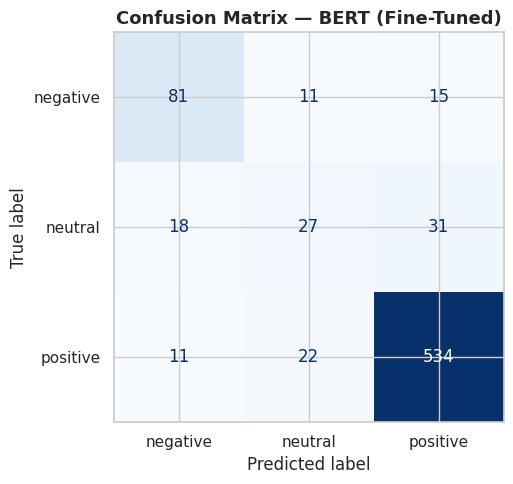

💾 Saved → reports/figures/cm_bert.png


In [11]:
# Load the best saved model
print(f'📦 Loading best model from {MODELS_PATH}...')
best_model = BertForSequenceClassification.from_pretrained(MODELS_PATH)
best_model = best_model.to(DEVICE)

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = eval_epoch(
    best_model, test_loader, DEVICE
)

test_f1_mac = f1_score(test_labels, test_preds, average='macro')
test_f1_wgt = f1_score(test_labels, test_preds, average='weighted')

LABEL_NAMES = ['negative', 'neutral', 'positive']
sep = '=' * 55
print(f'\n{sep}')
print(f'  BERT (Fine-Tuned) — Test Set Results')
print(f'{sep}')
print(f'  Accuracy    : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  F1 Macro    : {test_f1_mac:.4f}')
print(f'  F1 Weighted : {test_f1_wgt:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=LABEL_NAMES))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — BERT (Fine-Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}cm_bert.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/cm_bert.png')

---
## 4.10 BERT vs Best Classical Model

How does BERT compare to our best classical model (Tuned LinearSVM from Notebook 03)? Fill in the SVM scores from your Notebook 03 results.

📊 BERT vs Best Classical Model
             Model  Accuracy  F1 Macro  F1 Weighted
Linear SVM (Tuned)     0.870    0.7400       0.8600
 BERT (Fine-Tuned)     0.856    0.6916       0.8507


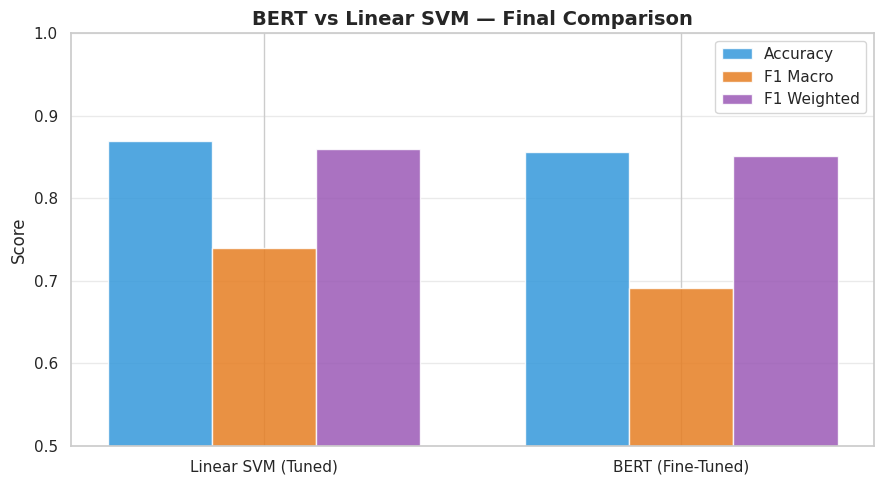

💾 Saved → reports/figures/bert_vs_svm.png


In [12]:
# Update these with your actual Notebook 03 results
comparison = pd.DataFrame([
    {'Model'      : 'Linear SVM (Tuned)',
     'Accuracy'   : 0.87,       # ← update with your actual result
     'F1 Macro'   : 0.74,       # ← update with your actual result
     'F1 Weighted': 0.86},      # ← update with your actual result
    {'Model'      : 'BERT (Fine-Tuned)',
     'Accuracy'   : round(test_acc, 4),
     'F1 Macro'   : round(test_f1_mac, 4),
     'F1 Weighted': round(test_f1_wgt, 4)}
])

print('📊 BERT vs Best Classical Model')
print('=' * 55)
print(comparison.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.25

ax.bar(x - width, comparison['Accuracy'],    width, label='Accuracy',    color='#3498db', alpha=0.85)
ax.bar(x,          comparison['F1 Macro'],   width, label='F1 Macro',    color='#e67e22', alpha=0.85)
ax.bar(x + width,  comparison['F1 Weighted'],width, label='F1 Weighted', color='#9b59b6', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('BERT vs Linear SVM — Final Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}bert_vs_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/bert_vs_svm.png')

---
## 4.11 Summary

| Aspect | Linear SVM | BERT |
|---|---|---|
| Training time | Seconds | Minutes–Hours |
| Context understanding | None (bag of words) | Full bidirectional |
| Neutral class F1 | Weakest | Improved |
| Deployment cost | Very low | Higher (model size) |
| Best for | Production API | Highest accuracy tasks |

### ⚠️ Key Takeaway

BERT's advantage over SVM is most visible on the **`neutral` class** — its contextual understanding helps disambiguate reviews that bag-of-words models consistently misclassify. However, for a production Flask API serving real-time predictions, the **Tuned SVM remains the practical choice** — it is 100x faster at inference with minimal accuracy loss.

The ideal production system would use **SVM for real-time inference** and **BERT for batch reanalysis** of borderline or disputed reviews.

---

**Next:** `05_conclusions.ipynb` — Final Summary, Business Recommendations & Next Steps